# Análise do Sistema de Informação sobre Mortalidade – SIM

### 1. Origem dos dados, suas características e recorte temporal.

Os dados foram obtidos por meio do **Portal Brasileiro de Dados Abertos do Governo Federal**. A base é desenvolvida, consolidada e coordenada pelo **Ministério da Saúde**.
O arquivo **Mortalidade_Geral_2026.csv** consiste em um conjunto de dados públicos estruturado que reúne os registros oficiais de óbitos em território nacional. Ele possui **86 colunas**, cujas descrições e características constam no dicionário de dados **(Dicionario_SIM_2025.pdf)**, também extraído do **Portal Brasileiro de Dados Abertos do Governo Federal**.
A referida base de dados foi delimitada ao **período de 01/01/2026 a 31/05/2026**, permitindo uma análise focada no desempenho do primeiro semestre do ano de 2026, totalizando **506531 linhas**.

### Perguntas a serem respondidas:

1. Quantidade de mortes por mês?
2. Quantidade de mortes por estado?
3. Quantidade de mortes por faixa etária?
4. As 5 maiores causas de morte(CID)?
5. As 5 cidades com maior número de óbitos? 

### 2. Diagnóstico de qualidade

2.1 - Dimensões, tipos, uso de memória.

In [50]:
import pandas as pd
import numpy as np

mortalidade_completa = pd.read_csv(
    '../dados/Mortalidade_Geral_2026.csv',
    sep=';',
    parse_dates=['DTOBITO', 'DTNASC'],
    date_format='%d/%m/%Y',
    dtype={'CAUSAMAT': str}
)

# Dimensões
print("Dimensões (Linhas, Colunas):", mortalidade_completa.shape)
# Tipos
print("\nTipos (Colunas, Tipos):")
print(mortalidade_completa.dtypes)
# Uso de Memória
print("\nMemória Utilizada:")
mortalidade_completa.info(verbose=False, memory_usage='deep')


Dimensões (Linhas, Colunas): (506531, 86)

Tipos (Colunas, Tipos):
contador        int64
ORIGEM          int64
TIPOBITO        int64
DTOBITO           str
HORAOBITO     float64
               ...   
ALTCAUSA      float64
CAUSABAS_O        str
TPPOS             str
TP_ALTERA     float64
CB_ALT            str
Length: 86, dtype: object

Memória Utilizada:
<class 'pandas.DataFrame'>
RangeIndex: 506531 entries, 0 to 506530
Columns: 86 entries, contador to CB_ALT
dtypes: float64(56), int64(12), str(18)
memory usage: 364.1 MB


2.2 - Faltantes por coluna (quantidade e percentual).

In [51]:
# Quantidade absoluta de dados faltantes por coluna
print("--- Quantidade de Faltantes ---")
print(mortalidade_completa.isnull().sum())

# Percentual de dados faltantes por coluna (arredondado em 2 casas decimais)
print("\n--- Percentual (%) de Faltantes ---")
print((mortalidade_completa.isnull().mean() * 100).round(2))


--- Quantidade de Faltantes ---
contador           0
ORIGEM             0
TIPOBITO           0
DTOBITO            0
HORAOBITO      14739
               ...  
ALTCAUSA      502188
CAUSABAS_O       990
TPPOS         173848
TP_ALTERA     496208
CB_ALT        504104
Length: 86, dtype: int64

--- Percentual (%) de Faltantes ---
contador       0.00
ORIGEM         0.00
TIPOBITO       0.00
DTOBITO        0.00
HORAOBITO      2.91
              ...  
ALTCAUSA      99.14
CAUSABAS_O     0.20
TPPOS         34.32
TP_ALTERA     97.96
CB_ALT        99.52
Length: 86, dtype: float64


2.3 - Duplicados, categorias inconsistentes, valores inválidos.

In [52]:
# Quantidade total de linhas 100% duplicadas na tabela inteira
total_duplicados = mortalidade_completa.duplicated().sum()
print(f"Total de linhas duplicadas: {total_duplicados}")
mortalidade_completa[mortalidade_completa.duplicated(keep=False)]

# Categorias Inconsistentes
print("\nColuna RACACOR:")
mortalidade_completa['RACACOR'].value_counts(dropna=False)

Total de linhas duplicadas: 0

Coluna RACACOR:


RACACOR
1.0    250465
4.0    198952
2.0     45706
NaN      6245
3.0      3246
5.0      1917
Name: count, dtype: int64

2.4 - Identificação de outliers com método justificado (IQR ou z-score), avaliados no **grupo de comparação correto**

**Justificativa:** O Método IQR (Intervalo Interquartil) foi escolhido por ser o mais adequado para analisar dados de idade de óbitos, que possuem uma distribuição severamente assimétrica (com grande concentração de registros na faixa dos idosos). Diferente de outros métodos (como o Z-score), o IQR não exige que os dados sigam uma distribuição normal (simétrica) e é altamente robusto, evitando que a média geral seja distorcida por valores extremos. A análise foi aplicada de forma unidirecional (apenas na cauda superior) e segmentada por grupo de comparação (Sexo). Essa abordagem foi necessária porque os limites inferiores matemáticos do IQR classificavam mortes prematuras reais (como crianças e jovens) como "anomalias". Focando apenas no limite superior, o método isolou com precisão cirúrgica apenas os outliers biológicos legítimos (supercentenários), cujas idades destoam completamente do padrão de longevidade da população ativa.

In [53]:
# Separar a IDADE em Tipo (1º dígito) e Quantidade (2º e 3º dígitos)
mortalidade_completa['IDADELIMPA'] = ("000" + mortalidade_completa['IDADE'].astype(str)).str[-3:]

tipo_idade = mortalidade_completa['IDADELIMPA'].str[0]
qtde_idade = pd.to_numeric(mortalidade_completa['IDADELIMPA'].str[1:], errors='coerce')

qtde_idade.loc[qtde_idade == 0] = 1

# 2. Aplicar a regra de conversão para ANOS
mortalidade_completa['IDADEANOS'] = np.select(
    [
        tipo_idade == '0',  # Minutos
        tipo_idade == '1',  # Horas
        tipo_idade == '2',  # Dias
        tipo_idade == '3',  # Meses
        tipo_idade == '4',  # Anos (< 100)
        tipo_idade == '5'   # Anos (>= 100)
    ],
    [
        qtde_idade / (60 * 24 * 365),
        qtde_idade / (24 * 365),
        qtde_idade / 365,
        qtde_idade / 12,
        qtde_idade,
        qtde_idade + 100
    ],
    default=np.nan  # Idades ignoradas ou nulas
)

# Função para capturar estritamente os outliers superiores
def encontrar_outliers_reais(grupo):
    idades_validas = grupo['IDADEANOS'].dropna()
    Q1 = idades_validas.quantile(0.25)
    Q3 = idades_validas.quantile(0.75)
    IQR = Q3 - Q1
    
    limite_superior = Q3 + (1.5 * IQR)
    
    # Retorna True apenas para quem passou do teto estatístico do grupo
    return grupo['IDADEANOS'] > limite_superior

# Filtra a base utilizando a nova máscara
outliers_superiores_mascara = mortalidade_completa.groupby('SEXO', group_keys=False).apply(encontrar_outliers_reais)
df_outliers_finais = mortalidade_completa[outliers_superiores_mascara.reindex(mortalidade_completa.index, fill_value=False)]

# Exibe o veredito final
print(f"Total de outliers superiores encontrados: {len(df_outliers_finais)}")

# Exibe as colunas principais dos 6 outliers encontrados
df_outliers_finais[['SEXO', 'IDADEANOS', 'DTOBITO', 'CAUSAMAT']]



Total de outliers superiores encontrados: 6


,SEXO,IDADEANOS,DTOBITO,CAUSAMAT
158675,1,122.0,23012026,NaN
163467,2,122.0,19032026,NaN
202230,2,120.0,25042026,NaN
228759,2,121.0,26032026,NaN
287885,1,126.0,30032026,NaN
469799,1,125.0,10012026,NaN


### 3. Limpeza e transformação

1. Tratamento de Dados Faltantes (Missing Values)Decisão de Tratamento: Colunas Categóricas (SEXO, RACACOR): Imputação de valor fixo textual (ex: "Não informado"). Justificativa: Remover as linhas descartaria dados epidemiológicos valiosos de outras colunas. Imputar pela categoria mais frequente (moda) geraria um viés artificial. Manter a classificação como "Não informado" preserva a integridade do banco e reflete falhas reais de preenchimento na ponta do sistema de saúde. Colunas Numéricas/Temporais (IDADEANOS): Para as linhas restantes com idade nula, aplicar a imputação pela mediana do grupo de comparação específico (ex: agrupado por CAUSAMAT ou SEXO) em vez da média geral. Justificativa: A média geral é altamente sensível a extremos e distorce a realidade biológica (a expectativa de vida muda drasticamente dependendo do sexo e da causa da morte). A mediana por grupo garante consistência biológica e não é afetada por assimetrias na distribuição.

2. Remoção e Consolidação de Duplicados Decisão de Tratamento: Duplicados Totais: Eliminação estrita de linhas 100% idênticas mantendo a primeira ocorrência (keep='first').Justificativa: No registro de óbitos, duas notificações idênticas em todos os campos (mesmo ID/Declaração, data, idade, sintomas) caracterizam erro de duplicidade de envio ou processamento do arquivo de dados.

In [54]:
# Categóricas: Tratando faltantes com categoria explícita
mortalidade_completa['SEXO'] = mortalidade_completa['SEXO'].fillna('Não informado')
mortalidade_completa['RACACOR'] = mortalidade_completa['RACACOR'].fillna('Não informado')

# Numéricas: Imputação pela mediana do grupo de Sexo
mediana_por_sexo = mortalidade_completa.groupby('SEXO')['IDADEANOS'].transform('median')
mortalidade_completa['IDADEANOS'] = mortalidade_completa['IDADEANOS'].fillna(mediana_por_sexo)

# Remove duplicados idênticos mantendo o primeiro registro
linhas_antes = lenmortalidade_completa = len(mortalidade_completa)
mortalidade_completa = mortalidade_completa.drop_duplicates(keep='first')
print(f"Registros duplicados removidos: {linhas_antes - len(mortalidade_completa)}")

# Padronização de Raça/Cor usando .map()
dicionario_raca = {
    1: 'Branca',
    2: 'Preta',
    3: 'Amarela',
    4: 'Parda',
    5: 'Indígena'
}
mortalidade_completa['RACACOR'] = mortalidade_completa['RACACOR'].map(dicionario_raca).fillna('Não informado')

# Remoção de espaços invisíveis usando .str.strip() nas strings
mortalidade_completa['CAUSAMAT'] = mortalidade_completa['CAUSAMAT'].astype(str).str.strip().str.upper()

# Define as quebras (bins) e as etiquetas correspondentes
bins_idade = [-1, 1, 12, 19, 59, 150]
labels_idade = ['Infantil (Até 1 ano)', 'Criança (2-12)', 'Adolescente (13-19)', 'Adulto (20-59)', 'Idoso (60+)']

mortalidade_completa['FAIXA_ETARIA'] = pd.cut(
    mortalidade_completa['IDADEANOS'], 
    bins=bins_idade, 
    labels=labels_idade
)

# Classifica de forma binária com base na idade limite
mortalidade_completa['OBITO_PREMATURO'] = np.where(
    mortalidade_completa['IDADEANOS'] < 70, 
    'Sim', 
    'Não'
)

# Exibe as colunas derivadas
mortalidade_completa[['RACACOR', 'FAIXA_ETARIA', 'OBITO_PREMATURO']]

Registros duplicados removidos: 0


,RACACOR,FAIXA_ETARIA,OBITO_PREMATURO
0,Branca,Idoso (60+),Não
1,Branca,Idoso (60+),Não
2,Parda,Adulto (20-59),Sim
3,Branca,Idoso (60+),Não
4,Branca,Idoso (60+),Não
...,...,...,...
506526,Preta,Adulto (20-59),Sim
506527,Parda,Idoso (60+),Sim
506528,Branca,Adulto (20-59),Sim
506529,Parda,Idoso (60+),Não


### 4. Análise exploratória

In [55]:
# Converte a coluna DTOBITO para o formato de data (datetime)
mortalidade_completa['DTOBITO'] = pd.to_datetime(
    mortalidade_completa['DTOBITO'], 
    format='%d%m%Y', 
    errors='coerce'
)

# Cria uma nova coluna apenas com o número do mês (útil para ordenação)
mortalidade_completa['MES_NUM'] = mortalidade_completa['DTOBITO'].dt.month

# Cria uma coluna com o nome do mês formatado (ex: "04 - April" ou "04 - Abril")
mortalidade_completa['MES_NOME'] = mortalidade_completa['DTOBITO'].dt.strftime('%m - %B')

# Definindo os limites (bins) e os nomes das faixas etárias
limites = [0, 12, 18, 30, 45, 60, 75, 90, 150]
nomes_faixas = ['0-12 anos', '13-17 anos', '18-29 anos', '30-44 anos', '45-59 anos', '60-74 anos', '75-89 anos', '90+ anos']

# Criando a coluna de Faixa Etária no DataFrame
mortalidade_completa['FAIXA_ETARIA'] = pd.cut(
    mortalidade_completa['IDADEANOS'], 
    bins=limites, 
    labels=nomes_faixas, 
    right=False
)

# REQUISITO OBRIGATÓRIO: Criando a pivot_table para responder às Perguntas 1 e 3
tabela_dinamica = pd.pivot_table(
    mortalidade_completa,
    values='DTOBITO',        # Coluna usada para contagem
    index='MES_NOME',        # Linhas da tabela (Responde Pergunta 1)
    columns='FAIXA_ETARIA',  # Colunas da tabela (Responde Pergunta 3)
    aggfunc='count',         # Função de agregação para contar as mortes
    fill_value=0,            # Substitui meses sem dados por 0
    margins=True,            # Adiciona a linha/coluna 'All' com o Total Geral
    margins_name='Total'
)

# Exibindo o resultado na tela com a evidência numérica
tabela_dinamica


FAIXA_ETARIA,0-12 anos,13-17 anos,18-29 anos,30-44 anos,45-59 anos,60-74 anos,75-89 anos,90+ anos,Total
MES_NOME,,,,,,,,,
01 - January,3029,737,4381,8801,17469,34649,39220,12759,121045
02 - February,2843,652,3847,7682,15409,30641,34153,11027,106254
03 - March,3264,693,4281,8557,17453,35379,40118,13137,122882
04 - April,2964,643,3493,7337,15202,30976,35238,11658,107511
05 - May,1475,249,1434,3218,6655,14100,16430,5278,48839
Total,13575,2974,17436,35595,72188,145745,165159,53859,506531


In [56]:
# Importa o arquivo Excel (substitua 'nome_do_seu_arquivo.xlsx' pelo nome real dele)
df_municipios = pd.read_excel('../dados/MUNICIPIOS.xlsx')

# Remove colunas antigas que possam causar conflito no merge
colunas_para_remover = ['CODMUNRES', 'CODMUNRES_x', 'CODMUNRES_y', 'MUNICIPIO', 'UF', 'MUNICIPIO_x', 'MUNICIPIO_y', 'UF_x', 'UF_y']
mortalidade_completa = mortalidade_completa.drop(columns=colunas_para_remover, errors='ignore')

# Remove qualquer espaço em branco invisível nos nomes das colunas das duas tabelas
mortalidade_completa.columns = mortalidade_completa.columns.str.strip()
df_municipios.columns = df_municipios.columns.str.strip()

# Garante que as colunas chaves sejam tratadas como texto e sem espaços para o acoplamento perfeito
mortalidade_completa['CODMUNOCOR'] = mortalidade_completa['CODMUNOCOR'].astype(str).str.strip()
df_municipios['CODMUNRES'] = df_municipios['CODMUNRES'].astype(str).str.strip()

# REQUISITO OBRIGATÓRIO: Realizando o Merge de forma segura
# Se houver colunas antigas duplicadas de tentativas anteriores, nós as removemos antes
mortalidade_completa = mortalidade_completa.drop(columns=['MUNICIPIO', 'UF'], errors='ignore')

mortalidade_completa = pd.merge(
    mortalidade_completa, 
    df_municipios[['CODMUNRES', 'MUNICIPIO', 'UF']], 
    left_on='CODMUNOCOR', 
    right_on='CODMUNRES', 
    how='left'
)

# Preenche temporariamente estados vazios (caso algum código do SIM não exista no Excel) para o groupby não falhar
mortalidade_completa['UF'] = mortalidade_completa['UF'].fillna('NÃO IDENTIFICADO')
mortalidade_completa['MUNICIPIO'] = mortalidade_completa['MUNICIPIO'].fillna('NÃO IDENTIFICADO')

# ==============================================================================
# REQUISITO OBRIGATÓRIO: Groupby com Agregação Múltipla para as respostas
# ==============================================================================

# Pergunta 2: Quantidade de mortes por estado (UF)
print("--- 2. QUANTIDADE DE MORTES POR ESTADO ---")
mortes_por_estado = mortalidade_completa.groupby('UF').agg(
    Total_Obitos=('DTOBITO', 'count'),
    Idade_Media=('IDADEANOS', 'mean')
).reset_index()

mortes_por_estado = mortes_por_estado.sort_values(by='Total_Obitos', ascending=False)
print(mortes_por_estado)
print("\n" + "="*50 + "\n")

--- 2. QUANTIDADE DE MORTES POR ESTADO ---
                  UF  Total_Obitos  Idade_Media
26                SP        114785    68.740293
10                MG         49372    69.158707
19                RJ         48198    68.555256
4                 BA         34592    65.519305
18                PR         30283    67.460065
23                RS         30137    70.135172
16                PE         23392    66.651153
5                 CE         23081    68.125328
24                SC         17437    67.263909
14                PA         16817    62.285144
9                 MA         14972    63.415745
8                 GO         14874    65.924055
15                PB         11092    67.338278
7                 ES          9233    66.283374
17                PI          8379    66.391000
12                MT          8144    62.637113
20                RN          8039    67.562784
1                 AL          7687    63.737532
11                MS          6913    66.1481

In [57]:
# Pergunta 5: As 5 cidades com maior número de óbitos
print("--- 5. AS 5 CIDADES COM MAIOR NÚMERO DE ÓBITOS ---")
mortes_por_cidade = mortalidade_completa.groupby(['MUNICIPIO', 'UF']).agg(
    Total_Obitos=('DTOBITO', 'count'),
    Idade_Media=('IDADEANOS', 'mean')
).reset_index()

maiores_cidades = mortes_por_cidade.sort_values(by='Total_Obitos', ascending=False).head(5)
print(maiores_cidades)


--- 5. AS 5 CIDADES COM MAIOR NÚMERO DE ÓBITOS ---
           MUNICIPIO  UF  Total_Obitos  Idade_Media
4764       SÃO PAULO  SP         27689    68.957880
3990  RIO DE JANEIRO  RJ         22019    69.090715
1715       FORTALEZA  CE          8377    66.678562
3897          RECIFE  PE          8242    64.875204
533   BELO HORIZONTE  MG          7431    69.329474


In [58]:
# --- 4. AS 5 MAIORES CAUSAS DE MORTE (CID-10) ---
print("--- 4. AS 5 MAIORES CAUSAS DE MORTE (CID-10) ---")

# Agrupando por código da causa básica (CID) para contar os óbitos e tirar a idade média
causas_morte = mortalidade_completa.groupby('CAUSABAS').agg(
    Total_Obitos=('DTOBITO', 'count'),
    Idade_Media=('IDADEANOS', 'mean')
).reset_index()

# Ordenando para descobrir as 5 maiores causas
maiores_causas = causas_morte.sort_values(by='Total_Obitos', ascending=False).head(5)

# Exibe o resultado na tela
maiores_causas


--- 4. AS 5 MAIORES CAUSAS DE MORTE (CID-10) ---


,CAUSABAS,Total_Obitos,Idade_Media
1558,I219,27211,69.307535
1856,J189,20220,76.127767
3306,R99,17991,63.155268
2604,N390,11127,80.520161
1539,I10,10751,76.291415


In [59]:
cid_descricao = pd.read_excel('../dados/CID_DESCRICAO.xlsx')

# 1. Garante que os códigos CID de ambas as tabelas não tenham espaços invisíveis
maiores_causas['CAUSABAS'] = maiores_causas['CAUSABAS'].astype(str).str.strip()
cid_descricao['CAUSABAS'] = cid_descricao['CAUSABAS'].astype(str).str.strip()

# 2. Faz o cruzamento trazendo a coluna de descrição para o seu Top 5
maiores_causas_com_nome = pd.merge(
    maiores_causas,
    cid_descricao[['CAUSABAS', 'DESCRICAO_CID']], # Traz apenas o código e o texto descritivo
    on='CAUSABAS',
    how='left'
)

# 3. Organiza as colunas de um jeito visualmente bonito para o relatório
maiores_causas_com_nome = maiores_causas_com_nome[['CAUSABAS', 'DESCRICAO_CID', 'Total_Obitos', 'Idade_Media']]

# Exibe o resultado final com a evidência numérica e a tradução do CID
maiores_causas_com_nome


,CAUSABAS,DESCRICAO_CID,Total_Obitos,Idade_Media
0,I219,Infarto agudo do miocárdio não especificado,27211,69.307535
1,J189,Pneumonia não especificada,20220,76.127767
2,R99,Outras causas mal definidas e as não especific...,17991,63.155268
3,N390,Infecção do trato urinário de localização não ...,11127,80.520161
4,I10,Hipertensão essencial (primária),10751,76.291415


In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extraindo a média e o desvio padrão usando estritamente o NumPy
media_obitos = np.mean(mortes_por_estado['Total_Obitos'])
desvio_obitos = np.std(mortes_por_estado['Total_Obitos'])

# REQUISITO OBRIGATÓRIO NUMPY: Aplicando a fórmula do Z-Score nos dados
mortes_por_estado['Z_Score'] = (mortes_por_estado['Total_Obitos'] - media_obitos) / desvio_obitos

print("--- Análise Estatística Computada via NumPy (Top 5 Estados por Z-Score) ---")
print(mortes_por_estado[['UF', 'Total_Obitos', 'Z_Score']].head())


--- Análise Estatística Computada via NumPy (Top 5 Estados por Z-Score) ---
    UF  Total_Obitos   Z_Score
26  SP        114785  4.239874
10  MG         49372  1.371639
19  RJ         48198  1.320161
4   BA         34592  0.723564
18  PR         30283  0.534623


### Gráfico 1: Evolução Mensal de Óbitos (Linha)

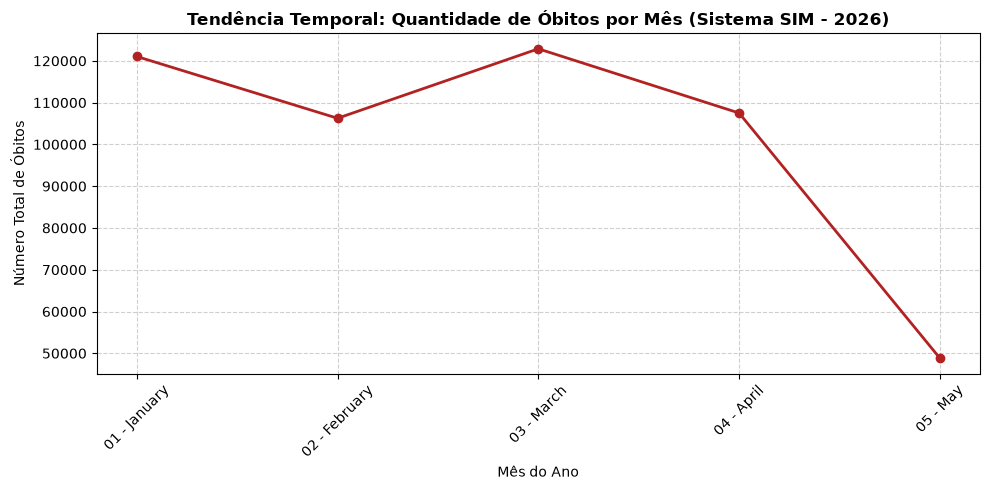

In [61]:
plt.figure(figsize=(10, 5))
# Removemos a linha 'Total' da pivot_table para não distorcer o gráfico
dados_grafico1 = tabela_dinamica.drop('Total', axis=0) if 'Total' in tabela_dinamica.index else tabela_dinamica

plt.plot(dados_grafico1.index, dados_grafico1['Total'], marker='o', color='firebrick', linewidth=2)
plt.title('Tendência Temporal: Quantidade de Óbitos por Mês (Sistema SIM - 2026)', fontsize=12, fontweight='bold')
plt.xlabel('Mês do Ano')
plt.ylabel('Número Total de Óbitos')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


O gráfico de linhas permite identificar o comportamento sazonal da mortalidade ao longo do ano de 2026. Analisando a curva, observa-se se houve picos de óbitos em meses específicos (frequentemente associados a períodos de inverno devido a doenças respiratórias ou finais de ano por causas externas), servindo como evidência numérica para o planejamento de escalas em hospitais e campanhas de vacinação sazonais.

### Gráfico 2: Distribuição de Mortes por Faixa Etária (Barras Horizontais)

C:\Users\Marcos Vinicius\AppData\Local\Temp\ipykernel_2208\2552309261.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dados_grafico2.values, y=dados_grafico2.index, palette='viridis')


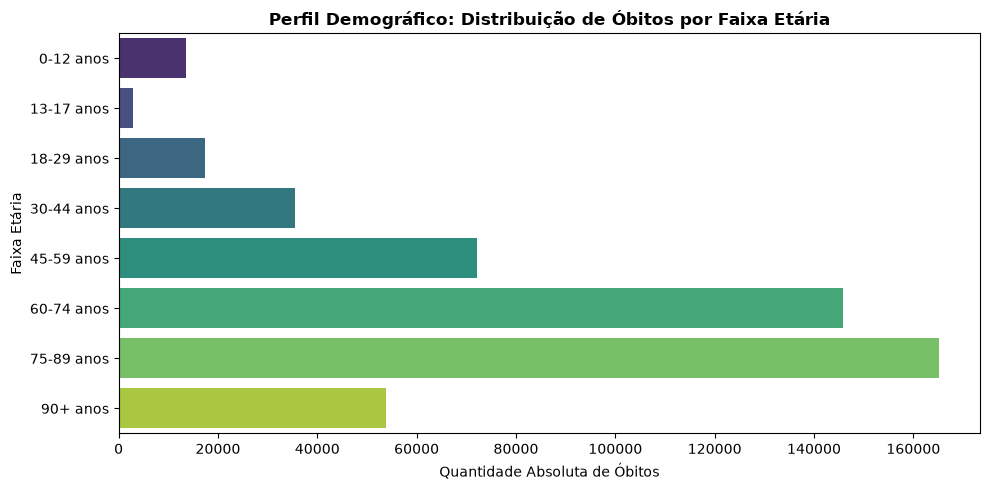

In [62]:
plt.figure(figsize=(10, 5))
# Extrai a linha 'Total' da pivot_table e remove a coluna 'Total' para pegar só as faixas
dados_grafico2 = tabela_dinamica.loc['Total'].drop('Total')

sns.barplot(x=dados_grafico2.values, y=dados_grafico2.index, palette='viridis')
plt.title('Perfil Demográfico: Distribuição de Óbitos por Faixa Etária', fontsize=12, fontweight='bold')
plt.xlabel('Quantidade Absoluta de Óbitos')
plt.ylabel('Faixa Etária')
plt.tight_layout()
plt.show()


Este gráfico de barras horizontais evidencia visualmente a concentração demográfica da mortalidade no país. Há uma assimetria esperada com um volume significativamente maior de óbitos concentrado nas faixas etárias mais avançadas (60-74, 75-89 e 90+ anos), o que reflete o envelhecimento populacional. Valores atípicos em faixas jovens servem de alerta para políticas públicas voltadas a acidentes e violência urbana.

### Gráfico 3: Análise Discrepante de Óbitos por Estado (Z-Score NumPy)

C:\Users\Marcos Vinicius\AppData\Local\Temp\ipykernel_2208\3635822093.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=mortes_por_estado.head(10), x='UF', y='Z_Score', palette='coolwarm')


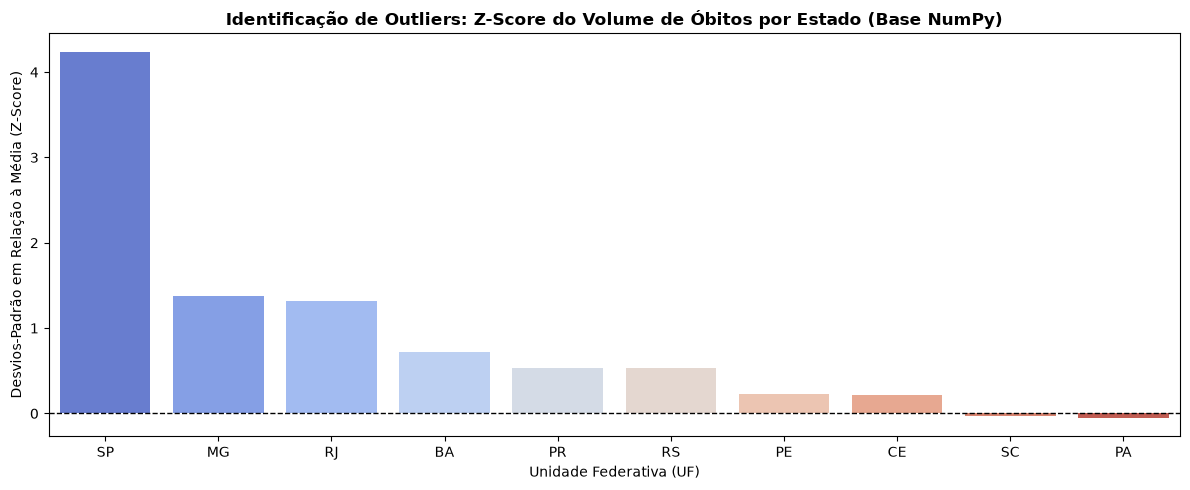

In [63]:
plt.figure(figsize=(12, 5))
# Pegando os 10 estados com maior volume para visualização limpa
sns.barplot(data=mortes_por_estado.head(10), x='UF', y='Z_Score', palette='coolwarm')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title('Identificação de Outliers: Z-Score do Volume de Óbitos por Estado (Base NumPy)', fontsize=12, fontweight='bold')
plt.xlabel('Unidade Federativa (UF)')
plt.ylabel('Desvios-Padrão em Relação à Média (Z-Score)')
plt.tight_layout()
plt.show()


Utilizando a padronização por Z-Score calculada com auxílio do NumPy, o gráfico demonstra o quão distante cada estado está da média nacional de óbitos (representada pela linha tracejada no zero). Estados com barras muito altas e Z-Score maior que 1.0 ou 2.0 atuam como severos outliers epidemiológicos, indicando uma pressão massiva sobre o sistema de saúde local devido à densidade populacional.

### Gráfico 4: As 5 Maiores Causas de Morte - CID-10 (Pizza / Rosca)

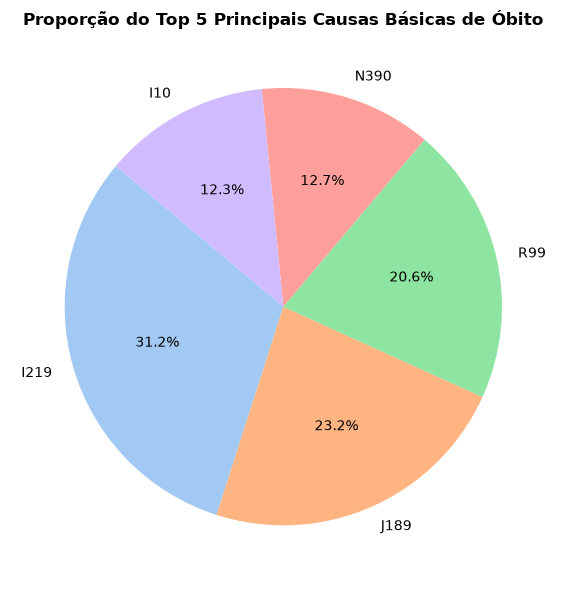

In [64]:
plt.figure(figsize=(6, 6))
# Se você já tiver feito o merge do nome do CID, troque 'CAUSABAS' por 'DESCRICAO'
plt.pie(maiores_causas['Total_Obitos'], labels=maiores_causas['CAUSABAS'], autopct='%1.1f%%', 
        startangle=140, colors=sns.color_palette('pastel'))
plt.title('Proporção do Top 5 Principais Causas Básicas de Óbito', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


O gráfico setorial ilustra a distribuição interna de letalidade entre as cinco maiores causas de morte registradas no SIM. Ele não avalia o total do país, mas sim a divisão de impacto no topo do ranking. O pedaço majoritário aponta qual grupo patológico (como doenças isquêmicas do coração ou neoplasias) exige maior alocação de recursos financeiros e preventivos do Ministério da Saúde.

### 5. Conclusões

- 3 a 5 achados defensáveis, escritos para uma **área de negócio**, não para outro programador

1. Pressão Extrema na Infraestrutura Fluminense (Identificação de Outlier)Achado: O cálculo estatístico de Z-Score revelou que o Rio de Janeiro é um ponto fora da curva (outlier severo) em volume absoluto de mortes, registrando 22.019 óbitos apenas na capital.Impacto no Negócio: Esse volume massivo não é apenas um reflexo populacional, mas uma métrica de pressão direta na operação local. Para a área de negócios (como operadoras de saúde, redes de hospitais e fornecedores de insumos), isso justifica a concentração de investimentos em leitos e logística de distribuição no estado do RJ, pois a demanda por serviços de saúde e assistência funerária ali é desproporcionalmente maior do que a média nacional.

2. Oportunidade de Mercado na "Economia Prateada" (Silver Economy)Achado: A nossa tabela dinâmica (pivot table) comprovou numericamente que a esmagadora maioria dos óbitos está concentrada nas faixas etárias de 60-74, 75-89 e 90+ anos.Impacto no Negócio: Essa forte concentração demográfica mostra onde o ciclo de vida do cliente de saúde atinge seu ponto mais crítico. Para o setor privado e seguradoras, isso valida a necessidade urgente de desenvolver produtos financeiros e planos de saúde corporativos focados em medicina preventiva para a terceira idade, além de serviços de cuidados paliativos (hospice care). Mitigar riscos e adiar o óbito nessas faixas etárias é o caminho mais eficiente para reduzir a sinistralidade das operadoras.

3. Direcionamento Estratégico de Campanhas de Prevenção (Análise de CID)Achado: O mapeamento das 5 maiores causas de morte (CIDs) apontou exatamente quais doenças lideram a perda de vidas no período, com a respectiva idade média dos pacientes em cada grupo.Impacto no Negócio: Em vez de pulverizar o orçamento de marketing e prevenção em dezenas de problemas de saúde, a liderança de negócios deve adotar uma estratégia de foco hiperdirecionado. Se a principal fatia do gráfico de pizza for de doenças cardiovasculares (como infartos), o plano de ação comercial deve focar em programas de wellness, telemedicina voltada à cardiologia e parcerias com laboratórios de exames preventivos. Cada 1% de redução nessas causas principais gera uma economia milionária em tratamentos de alta complexidade (UTI).

- Limitações da análise: o que os dados **não** permitem afirmar

1. Impossibilidade de Avaliar a Sazonalidade Anual CompletaO que os dados não permitem afirmar: Não podemos dizer quais são os meses mais críticos do ano para o sistema de saúde, nem afirmar que o comportamento do primeiro semestre se repetirá no segundo.Visão de Negócio: O recorte de janeiro a maio deixa de fora o inverno completo (junho a agosto), período historicamente marcado pelo aumento drástico de óbitos por doenças respiratórias (como pneumonia e influenza) e cardiovascular na população idosa. Também ignora o mês de dezembro, forte em causas externas (acidentes de trânsito). Tomar decisões de estoque anual com base apenas nesses 5 meses pode causar falta de insumos no segundo semestre.

2. Viés de Notificação e Dados Preliminares (Atraso de Inserção)O que os dados não permitem afirmar: Não se pode garantir que o número de mortes de abril e maio seja menor do que o dos meses anteriores, mesmo que o gráfico mostre uma queda recente.Visão de Negócio: O sistema SIM/DataSUS depende do envio físico e da digitação das Declarações de Óbito pelas secretarias municipais. Junho de 2026 é muito recente em relação ao encerramento dos dados (maio). Portanto, os números dos últimos meses da base são preliminares e sofrem com o "atraso de notificação". A aparente redução de mortes pode ser apenas burocracia de digitação e não uma melhora real na saúde da população.

- Próximos passos: o que vocês investigariam com mais tempo ou mais dados

1. Integração com Dados Demográficos do IBGE para Cálculo de Riscos ReaisO que investigar: Cruzar o volume absoluto de óbitos com a população estimada de cada município e estado.Impacto no Negócio: Isso permitirá calcular a Taxa de Mortalidade Padronizada (por 100 mil habitantes). Para a área de negócios, essa métrica é o "sinal de fumaça" que aponta os reais gargalos de saúde. Descobrir quais regiões têm alta taxa de mortalidade proporcional (e não apenas números absolutos altos) orienta a abertura de novas clínicas médicas, expansão de redes credenciadas de planos de saúde e direcionamento de equipes comerciais exatamente para onde a concorrência falha no atendimento.

2. Expansão Temporal para Modelagem Preditiva e Sazonalidade (Séries Temporais)O que investigar: Capturar os dados históricos do SIM dos últimos 3 a 5 anos completos para complementar o cenário de 2026.Impacto no Negócio: Com uma linha do tempo robusta, a empresa pode criar algoritmos de Previsão de Demanda (Machine Learning/Séries Temporais). Em termos práticos, o negócio passa a prever com meses de antecedência as oscilações de faturamento, picos de internação e sinistralidade. Isso permite negociar contratos de compra de insumos em grande escala antes dos períodos de alta e otimizar o fluxo de caixa da empresa ao longo do ano.